<a href="https://colab.research.google.com/github/Ayush-Gole8/DeepLearning/blob/main/23102A0005_DL_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading and preprocessing MNIST dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Applying Gaussian noise (Factor: 0.5)...
Building Convolutional Denoising Autoencoder...

--- Training Model ---
Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 0.1664 - mse: 0.0335 - val_loss: 0.1168 - val_mse: 0.0178 - learning_rate: 0.0010
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1134 - mse: 0.0166 - val_loss: 0.1084 - val_mse: 0.0150 - learning_rate: 0.0010
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1076 - mse: 0.0147 - val_loss: 0.1047 - val_mse: 0.0138 - learning_rate: 0.0010
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1045 - mse: 0.0137 - val_loss: 0.1022 - val_mse: 0.0131 - learning_rate: 0.0010
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1025 - mse: 0.0130 - val_loss: 0.1008 - val_mse: 0.0125 - learning_rate: 0.0010
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.1012 - mse: 0.0126 

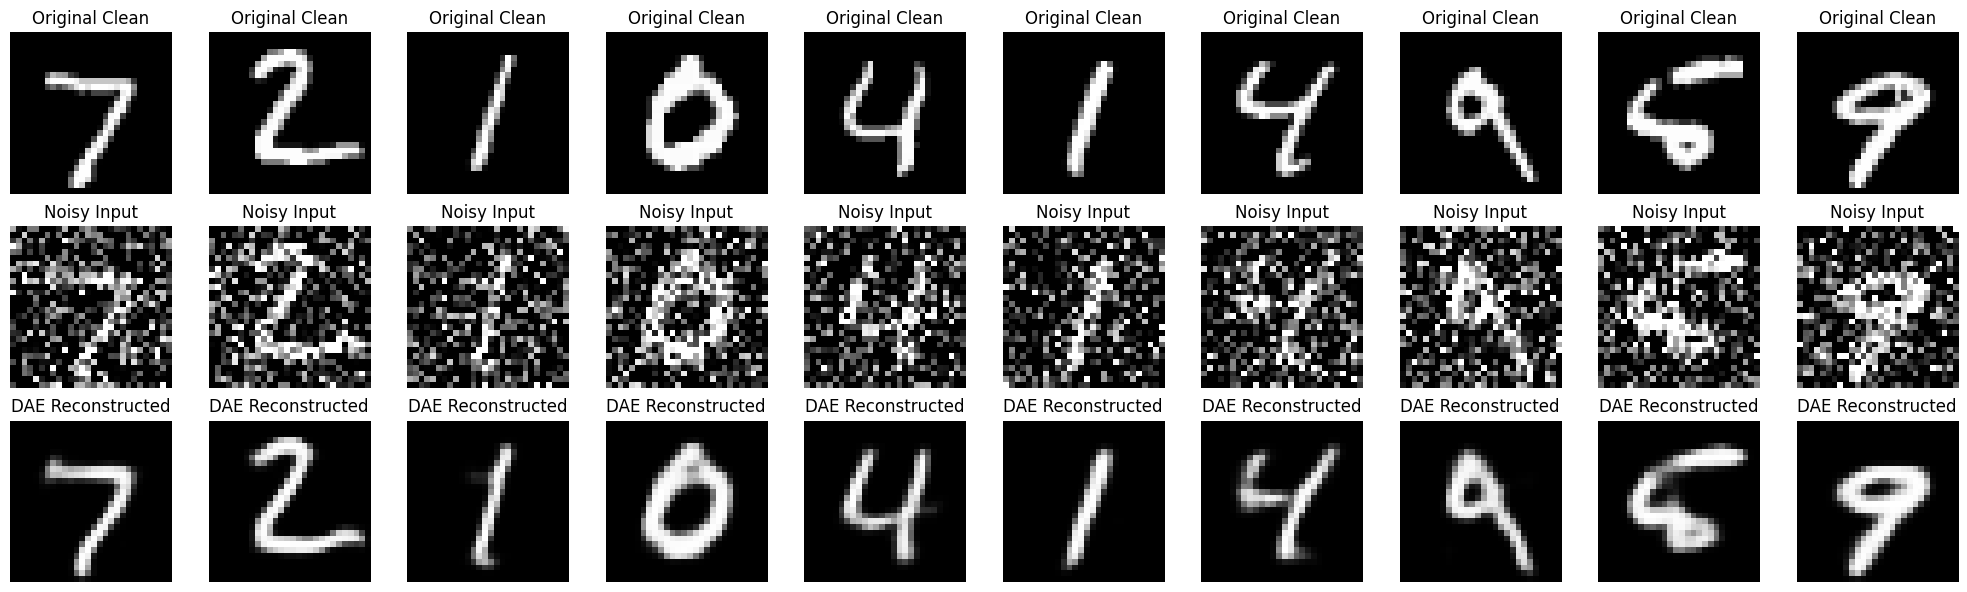

In [1]:
# ==========================================
# DENOISING AUTOENCODER EXPERIMENT
# RECONSTRUCTING CORRUPTED MNIST DIGITS
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ==========================================
# HYPERPARAMETER CONFIGURATION
# ==========================================
CONFIG = {
    "NOISE_FACTOR": 0.5,
    "BATCH_SIZE": 128,
    "EPOCHS": 50,
    "PATIENCE": 10,
    "LEARNING_RATE": 0.001,
    "RANDOM_SEED": 42
}

tf.random.set_seed(CONFIG["RANDOM_SEED"])
np.random.seed(CONFIG["RANDOM_SEED"])

# ==========================================
# 1. DATASET PREPARATION & PREPROCESSING
# ==========================================
print("Loading and preprocessing MNIST dataset...")
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

# ==========================================
# 2. APPLY SYNTHETIC NOISE (CORRUPTION)
# ==========================================
print(f"Applying Gaussian noise (Factor: {CONFIG['NOISE_FACTOR']})...")

x_train_noisy = x_train + CONFIG["NOISE_FACTOR"] * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + CONFIG["NOISE_FACTOR"] * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# ==========================================
# 3. BUILD CONVOLUTIONAL AUTOENCODER
# ==========================================
print("Building Convolutional Denoising Autoencoder...")

# ENCODER
input_img = Input(shape=(28, 28, 1), name="Input_Layer")
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same', name="Latent_Space_Bottleneck")(x)

# DECODER
x = Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="Output_Layer")(x)

autoencoder = Model(input_img, decoded)

# Using Adam optimizer with a defined learning rate, tracking MSE explicitly
autoencoder.compile(optimizer=Adam(learning_rate=CONFIG["LEARNING_RATE"]),
                    loss='binary_crossentropy',
                    metrics=['mse'])

# ==========================================
# 4. ADVANCED TRAINING ROUTINE
# ==========================================
print("\n--- Training Model ---")

# Halt training if no improvement after 10 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=CONFIG["PATIENCE"], restore_best_weights=True, verbose=1)

# Drop learning rate by 50% if validation loss stalls for 4 epochs (refines edge details)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=0.00001, verbose=1)

history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=CONFIG["EPOCHS"],
    batch_size=CONFIG["BATCH_SIZE"],
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ==========================================
# 5. METRICS CALCULATION (MSE & SSIM)
# ==========================================
print("\nCalculating Evaluation Metrics...")
decoded_imgs = autoencoder.predict(x_test_noisy, verbose=0)

mse = np.mean(np.square(x_test - decoded_imgs))

x_test_tf = tf.convert_to_tensor(x_test)
decoded_imgs_tf = tf.convert_to_tensor(decoded_imgs)
ssim = tf.reduce_mean(tf.image.ssim(x_test_tf, decoded_imgs_tf, max_val=1.0)).numpy()

print("==========================================")
print("FINAL RECONSTRUCTION METRICS")
print("==========================================")
print(f"Mean Squared Error (MSE): {mse:.4f} (Closer to 0 is better)")
print(f"Structural Similarity (SSIM): {ssim:.4f} (Closer to 1.0 is better)")

# ==========================================
# 6. VISUALIZATION & DIAGRAM SAVING
# ==========================================
n = 10
plt.figure(figsize=(20, 6))

for i in range(n):
    # Top Row: Original Clean Images
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original Clean", fontsize=12)
    plt.axis("off")

    # Middle Row: Noisy Corrupted Images
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy Input", fontsize=12)
    plt.axis("off")

    # Bottom Row: Reconstructed Denoised Images
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("DAE Reconstructed", fontsize=12)
    plt.axis("off")

plt.tight_layout()

image_path = 'denoising_autoencoder_results.png'
plt.savefig(image_path, dpi=300)
print(f"\n✅ Plot saved successfully to Colab environment as: {image_path}")

plt.show()

Loading and preprocessing MNIST dataset...


/usr/local/lib/python3.13/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(



--- Symmetrical Tight Bottleneck Architecture ---


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Latent_Space_Bottleneck         │ (None, 7, 7, 4)        │           580 │
│ (Conv2D)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 4)        │            16 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 7, 7, 4)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 7, 7, 16)       │           592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 7, 7, 16)       │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_22 (UpSampling2D) │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_23 (UpSampling2D) │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Conv2D)           │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,445 (44.71 KB)

 Trainable params: 11,245 (43.93 KB)

 Non-trainable params: 200 (800.00 B)


STARTING EXPERIMENT: NOISE FACTOR = 0.3
Epoch 1/30
469/469 - 17s - 37ms/step - loss: 0.0237 - mse: 0.0237 - val_loss: 0.0126 - val_mse: 0.0126 - learning_rate: 0.0010
Epoch 2/30
469/469 - 4s - 8ms/step - loss: 0.0098 - mse: 0.0098 - val_loss: 0.0087 - val_mse: 0.0087 - learning_rate: 0.0010
Epoch 3/30
469/469 - 3s - 7ms/step - loss: 0.0083 - mse: 0.0083 - val_loss: 0.0077 - val_mse: 0.0077 - learning_rate: 0.0010
Epoch 4/30
469/469 - 3s - 7ms/step - loss: 0.0076 - mse: 0.0076 - val_loss: 0.0073 - val_mse: 0.0073 - learning_rate: 0.0010
Epoch 5/30
469/469 - 3s - 7ms/step - loss: 0.0072 - mse: 0.0072 - val_loss: 0.0070 - val_mse: 0.0070 - learning_rate: 0.0010
Epoch 6/30
469/469 - 4s - 8ms/step - loss: 0.0069 - mse: 0.0069 - val_loss: 0.0068 - val_mse: 0.0068 - learning_rate: 0.0010
Epoch 7/30
469/469 - 3s - 7ms/step - loss: 0.0066 - mse: 0.0066 - val_loss: 0.0066 - val_mse: 0.0066 - learning_rate: 0.0010
Epoch 8/30
469/469 - 3s - 7ms/step - loss: 0.0064 - mse: 0.0064 - val_loss: 0.0065

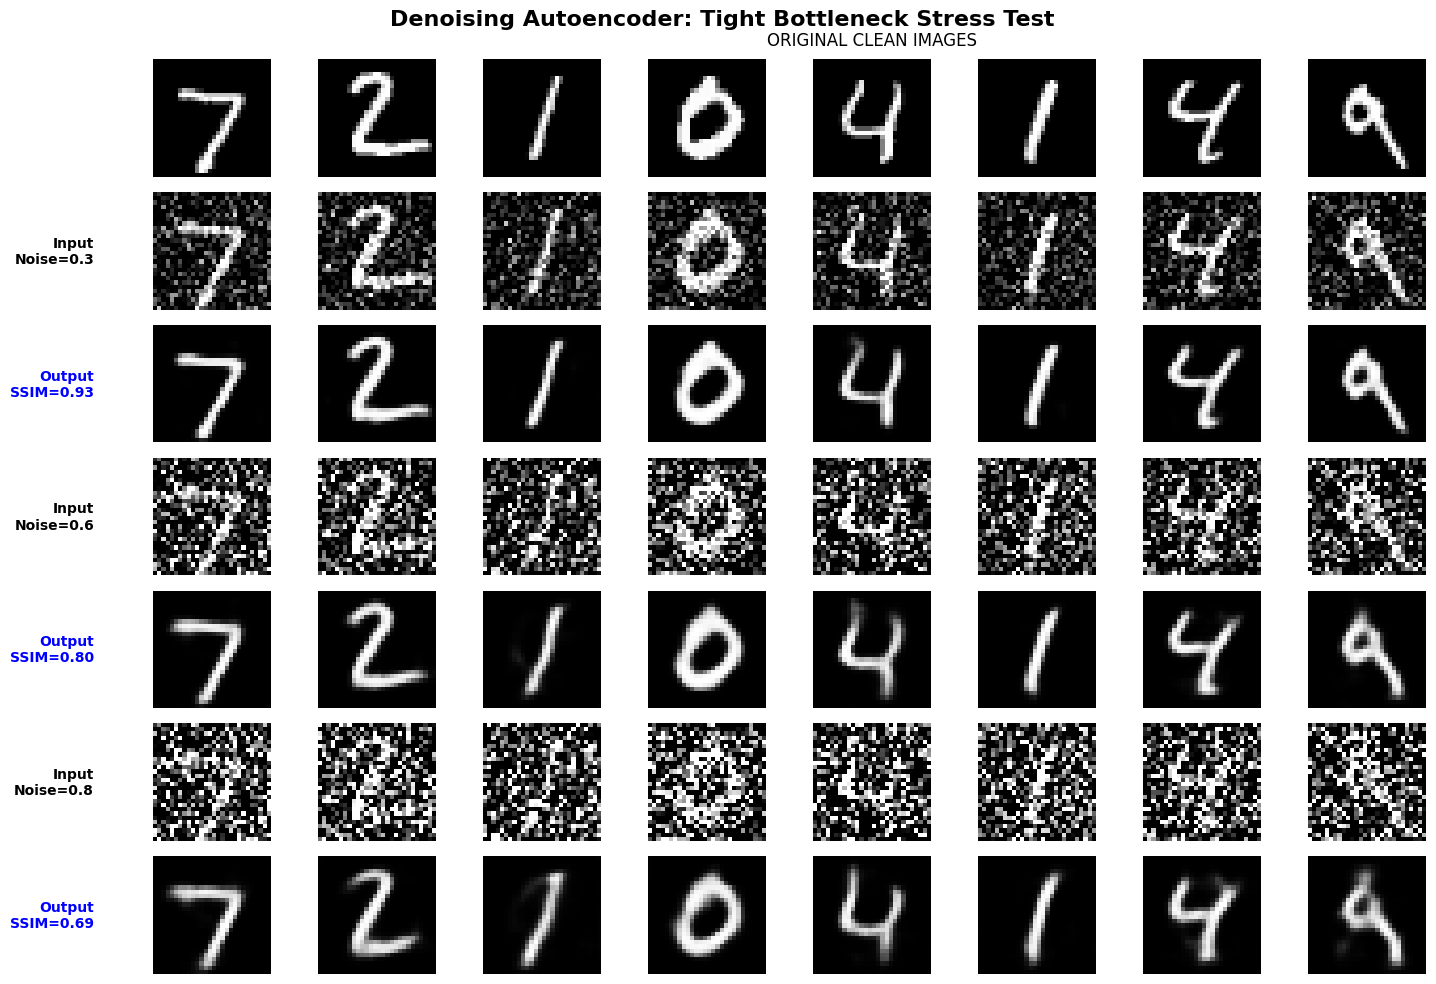

In [4]:
"""
Denoising Autoencoder — Bottleneck Stress Test
================================================
Trains a compact convolutional autoencoder to denoise MNIST digits at three
Gaussian noise levels (0.3, 0.6, 0.8) and compares reconstruction quality
via SSIM and MSE."""
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, UpSampling2D, BatchNormalization, LeakyReLU
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.initializers import HeNormal


CONFIG = {
    "NOISE_FACTORS": [0.3, 0.6, 0.8],
    "BATCH_SIZE": 128,
    "EPOCHS": 30,
    "PATIENCE": 5,
    "LEARNING_RATE": 0.001,
    "RANDOM_SEED": 42,
    "COLLAPSE_STD_THRESHOLD": 0.01,
}


def set_seeds(seed):
    """Seed TensorFlow and NumPy for reproducible experiments."""
    tf.random.set_seed(seed)
    np.random.seed(seed)


def load_mnist():
    """Load and normalize MNIST into (N, 28, 28, 1) float32 arrays in [0, 1]."""
    (x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()
    x_train = x_train.astype("float32") / 255.0
    x_test = x_test.astype("float32") / 255.0
    x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
    x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))
    return x_train, x_test


def add_gaussian_noise(images, noise_factor, seed):
    """Add clipped Gaussian noise to a batch of images using an isolated RNG."""
    rng = np.random.default_rng(seed)
    noisy = images + noise_factor * rng.normal(loc=0.0, scale=1.0, size=images.shape)
    return np.clip(noisy, 0.0, 1.0).astype("float32")


def conv_block(x, filters, name=None):
    """Conv2D -> BatchNorm -> LeakyReLU, with He-normal init to avoid dead units."""
    x = Conv2D(filters, (3, 3), padding="same", kernel_initializer=HeNormal(), name=name)(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(alpha=0.1)(x)
    return x


def build_autoencoder(learning_rate):
    """Build and compile the symmetric tight-bottleneck denoising autoencoder."""
    input_img = Input(shape=(28, 28, 1), name="Input_Layer")

    x = conv_block(input_img, 32)
    x = MaxPooling2D((2, 2), padding="same")(x)

    x = conv_block(x, 16)
    x = MaxPooling2D((2, 2), padding="same")(x)

    encoded = conv_block(x, 4, name="Latent_Space_Bottleneck")

    x = conv_block(encoded, 16)
    x = UpSampling2D((2, 2))(x)

    x = conv_block(x, 32)
    x = UpSampling2D((2, 2))(x)

    decoded = Conv2D(1, (3, 3), activation="sigmoid", padding="same",
                      kernel_initializer=HeNormal(), name="Output_Layer")(x)

    autoencoder = Model(input_img, decoded)
    autoencoder.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="mean_squared_error",
        metrics=["mse"],
    )
    return autoencoder


def check_for_collapse(reconstructions, threshold):
    """Flag a network that has collapsed to a near-constant, input-independent output."""
    per_image_std = reconstructions.reshape(len(reconstructions), -1).std(axis=1)
    mean_std = float(per_image_std.mean())
    collapsed = mean_std < threshold
    if collapsed:
        print(f"WARNING: possible dead-network collapse - mean per-image std = {mean_std:.5f}")
    return collapsed, mean_std


def run_experiment(noise_factor, x_train, x_test, config):
    """Train and evaluate one autoencoder at a given noise level."""
    print(f"\n{'=' * 50}")
    print(f"STARTING EXPERIMENT: NOISE FACTOR = {noise_factor}")
    print(f"{'=' * 50}")

    set_seeds(config["RANDOM_SEED"])

    x_train_noisy = add_gaussian_noise(x_train, noise_factor, seed=config["RANDOM_SEED"])
    x_test_noisy = add_gaussian_noise(x_test, noise_factor, seed=config["RANDOM_SEED"] + 1)

    autoencoder = build_autoencoder(config["LEARNING_RATE"])

    early_stop = EarlyStopping(monitor="val_loss", patience=config["PATIENCE"],
                                restore_best_weights=True, verbose=1)
    reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2,
                                   min_lr=1e-5, verbose=1)

    autoencoder.fit(
        x_train_noisy, x_train,
        epochs=config["EPOCHS"],
        batch_size=config["BATCH_SIZE"],
        shuffle=True,
        validation_data=(x_test_noisy, x_test),
        callbacks=[early_stop, reduce_lr],
        verbose=2,
    )

    decoded_imgs = autoencoder.predict(x_test_noisy, verbose=0)
    mse_score = float(np.mean(np.square(x_test - decoded_imgs)))

    x_test_tf = tf.convert_to_tensor(x_test)
    decoded_imgs_tf = tf.convert_to_tensor(decoded_imgs)
    ssim_score = float(tf.reduce_mean(tf.image.ssim(x_test_tf, decoded_imgs_tf, max_val=1.0)).numpy())

    collapsed, mean_std = check_for_collapse(decoded_imgs, config["COLLAPSE_STD_THRESHOLD"])

    status = " (COLLAPSED)" if collapsed else ""
    print(f"\n--> RESULTS FOR NOISE {noise_factor} | SSIM: {ssim_score:.4f} | "
          f"MSE: {mse_score:.4f} | Output std: {mean_std:.4f}{status}")

    return {
        "noise": noise_factor,
        "ssim": ssim_score,
        "mse": mse_score,
        "output_std": mean_std,
        "collapsed": collapsed,
        "noisy_inputs": x_test_noisy,
        "reconstructions": decoded_imgs,
    }


def plot_results(x_test, results, n=8, save_path="dae_stress_test_results.png"):
    """Plot original, noisy, and reconstructed rows for every noise level tested."""
    fig, axes = plt.subplots(len(results) * 2 + 1, n, figsize=(15, 10))
    fig.suptitle("Denoising Autoencoder: Tight Bottleneck Stress Test",
                  fontsize=16, fontweight="bold", y=0.98)

    for i in range(n):
        axes[0, i].imshow(x_test[i].reshape(28, 28), cmap="gray")
        axes[0, i].axis("off")
        if i == n // 2:
            axes[0, i].set_title("ORIGINAL CLEAN IMAGES", fontsize=12, pad=10)

    row = 1
    for result in results:
        noisy = result["noisy_inputs"]
        reconstructed = result["reconstructions"]

        for i in range(n):
            axes[row, i].imshow(noisy[i].reshape(28, 28), cmap="gray")
            axes[row, i].axis("off")
            if i == 0:
                axes[row, i].text(-0.5, 0.5, f"Input\nNoise={result['noise']}",
                                   va="center", ha="right", transform=axes[row, i].transAxes,
                                   fontsize=10, fontweight="bold")
        row += 1

        for i in range(n):
            axes[row, i].imshow(reconstructed[i].reshape(28, 28), cmap="gray")
            axes[row, i].axis("off")
            if i == 0:
                axes[row, i].text(-0.5, 0.5, f"Output\nSSIM={result['ssim']:.2f}",
                                   va="center", ha="right", transform=axes[row, i].transAxes,
                                   fontsize=10, fontweight="bold", color="blue")
        row += 1

    plt.tight_layout()
    plt.subplots_adjust(left=0.1, top=0.93)
    plt.savefig(save_path, dpi=300)
    print(f"Final visualization saved to: {save_path}")


def main():
    """Run the full noise-level stress test end to end."""
    set_seeds(CONFIG["RANDOM_SEED"])

    print("Loading and preprocessing MNIST dataset...")
    x_train, x_test = load_mnist()

    probe_model = build_autoencoder(CONFIG["LEARNING_RATE"])
    print("\n--- Symmetrical Tight Bottleneck Architecture ---")
    probe_model.summary()
    del probe_model

    results = [run_experiment(noise, x_train, x_test, CONFIG) for noise in CONFIG["NOISE_FACTORS"]]

    plot_results(x_test, results)

    print("\n=== EXPERIMENT SUMMARY ===")
    for r in results:
        flag = " (COLLAPSED)" if r["collapsed"] else ""
        print(f"Noise Factor: {r['noise']} --> SSIM: {r['ssim']:.4f} | MSE: {r['mse']:.4f}{flag}")


if __name__ == "__main__":
    main()